# Proyecto de Vision por Computador Semana 3

## GRUPO 6 - PARALELO B
- CHILUISA GALLARDO ROBINSON
- LANCHIMBA CAIZA NATALY FERNANDA
- CHOEZ ARTEAGA TEOFILO MANUEL

### **Step 1: Install Required Dependencies**

In [1]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install roboflow
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


### **Step 2: Import Required Libraries**

In [2]:
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

### Se selecciono las clases (alicate y dron) las cuales no se encuentran dentro de la base de datos de Yolo

In [36]:
# Initialize RoboFlow (you'll need your API key)


!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="cqDDHGLbzmBxe8kmRA7g")
project = rf.workspace("robinsons-workspace-4qhg1").project("deteccion-de-objetos-pfrot")
version = project.version(2)
dataset = version.download("yolo26")
                
            


loading Roboflow workspace...
loading Roboflow project...


### Carga de las 50 imagenes en roboflow, 25 por clase
![Interfaz Streamlit - Imagen](../Dataset/datos.JPG "Interfaz principal de Streamlit")

### **Step 6: Train Your Custom YOLO Model**

In [37]:
# Load the YOLO model with custom configuration
model = YOLO('yolo26s.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=140,  # Number of training epochs
    imgsz=640,  # Image size
    batch=16,   # Batch size
    name='custom_yolo_model'  # Name for the training run
)

Ultralytics 8.4.26  Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1060, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Code\deteccion-de-objetos-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=140, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_model4, nbs=64, nms=Fal

### **Step 7: Evaluate Your Model**

In [38]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

# Show some validation results
!yolo task=detect mode=val model=runs/detect/custom_yolo_model/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.26  Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1060, 6144MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 283.5153.8 MB/s, size: 48.0 KB)
val: Scanning D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Code\deteccion-de-objetos-2\valid\labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 9.7s/it 9.7s
                   all         10         10          1       0.92      0.932      0.608
               alicate          3          3          1      0.995      0.995      0.687
                  dron          7          7          1      0.844      0.869      0.529
Speed: 2.7ms preprocess, 18.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Co

## Analisis de los resultados

### El mAP@50 cercano a 0.9, esto nos indica que el sistema identifica de manera confiable las clases (alicate y dron) en la mayoría de los casos, se observada el mAP@50–95 es menor (~0.65) esta métrica es más estricta, detecta desviaciones en la localizacion, aunque los objetos son detectados correctamente, la precisión en el ajuste exacto de las cajas delimitadoras puede mejorarse modificando los valores del modelo.

### **Step 8: Test Your Custom Model on an Image**


image 1/1 D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Dataset\prueba2.jpeg: 640x384 1 alicate, 1 dron, 42.9ms
Speed: 3.1ms preprocess, 42.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)


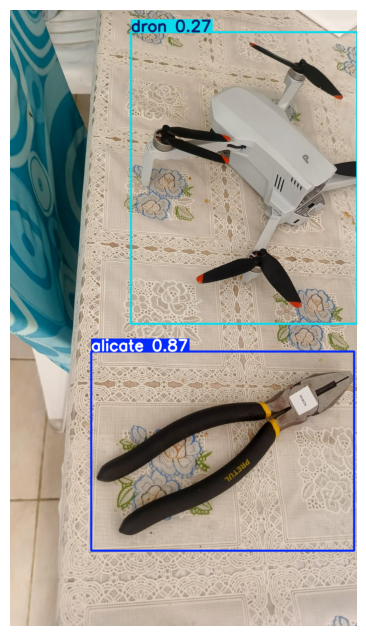

In [39]:
# Load your custom trained model
custom_model = YOLO(r'D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Code\runs\detect\custom_yolo_model2\weights\best.pt')

# Test on a sample image
results = custom_model(r'D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Dataset\prueba2.jpeg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

### **Step 9: Test Your Custom Model on Video**

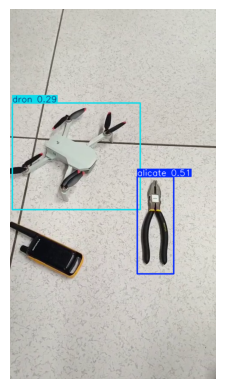

✅ Video guardado en: D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Dataset\video2_detectado.mp4


In [40]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Cargar modelo
model = YOLO(
    r'D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Code\runs\detect\custom_yolo_model2\weights\best.pt'
)

video_path = r'D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Dataset\video2.mp4'
output_path = r'D:\REPOSITORIO\VisionporComputador\ProyectoSemanaTres\src\Dataset\video2_detectado.mp4'

cap = cv2.VideoCapture(video_path)

# Propiedades del video original
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Configurar escritor de video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

plt.figure(figsize=(10, 6))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.25)
    annotated_frame = results[0].plot()

    # Guardar frame detectado (BGR)
    out.write(annotated_frame)

    # Mostrar en Jupyter (RGB)
    frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

cap.release()
out.release()

print("✅ Video guardado en:", output_path)

### Se detecto que el modelo tiende a demorarse en detectar el objeto, esto puede ser a que no se le entrono con una base de datos masiva, se obtuvieron buenos resultados en la deteccion de la imagen y el video con confiabilidad superior al 0.3 

## **Activity: Create Your Custom Detector**

1. **Create a RoboFlow account** and set up a new project
2. **Upload at least 25 images** of your custom objects (at least 2)
3. **Annotate all images** with bounding boxes and class labels
4. **Train a YOLO model** on your custom dataset
5. **Test your model** on new images and evaluate its performance
6. **Implement real-time detection** with your custom classes

## **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Dataset Creation** | 4 | Successfully creates and annotates a custom dataset with at least 25 images and multiple classes in RoboFlow. |
| **2. Model Training** | 1 | Properly trains a YOLOv8 model on the custom dataset with appropriate hyperparameters. |
| **3. Model Evaluation** | 1 | Evaluates model performance with appropriate metrics and provides analysis of results. |
| **4. Custom Detection** | 3 | Implements real-time detection with custom classes and displays results correctly. You have to use video from your webcam, no images or saved videos allowed. |
| **5. Documentation** | 1 | Provides clear documentation of the process, including dataset details and model performance. |

**Total: 10 points**

## **Tips for Success:**

- **Quality over quantity**: Well-annotated images are more important than many poorly annotated ones
- **Class balance**: Try to have a similar number of examples for each class
- **Variety**: Include different angles, lighting conditions, and backgrounds
- **Augmentation**: Use RoboFlow's augmentation features to expand your dataset

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>